# Krok 7 — Finální výstup & Segmentace zákazníků

| Položka | Hodnota |
|---------|---------|
| **Projekt** | CLV Predikce 2025 |
| **Krok** | 7 / 7 |
| **Datum** | 2025-06-01 |
| **Autor** | Datový analytik |
| **Verze** | 1.0 |

**Cíl notebooku:**  
Sestavit finální business výstup projektu. Načíst predikce XGBoost pro všech 1 200 zákazníků,  
přiřadit každému CLV segment (High / Medium / Low), vizualizovat rozložení segmentů  
a jejich charakteristiky. Prezentovat kompletní srovnávací tabulku všech modelů  
a dodat interpretovatelný zákaznický výstup připravený pro business použití.


## 2. Imports & Setup

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# Segmentační prahy — fixní business thresholds
CLV_THRESHOLD_LOW    =  5_000   # < 5 000 → Low
CLV_THRESHOLD_MEDIUM = 25_000   # 5 000–25 000 → Medium; ≥ 25 000 → High

INPUT_DIR  = Path("outputs")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

SEGMENT_ORDER  = ["High", "Medium", "Low"]
SEGMENT_COLORS = {
    "High":   "#2196F3",
    "Medium": "#FFC107",
    "Low":    "#9E9E9E",
}

print("Prostředí inicializováno.")
print(f"  Segmentační prahy: Low < {CLV_THRESHOLD_LOW:,} | "
      f"Medium {CLV_THRESHOLD_LOW:,}–{CLV_THRESHOLD_MEDIUM:,} | "
      f"High ≥ {CLV_THRESHOLD_MEDIUM:,}")


Prostředí inicializováno.
  Segmentační prahy: Low < 5,000 | Medium 5,000–25,000 | High ≥ 25,000


## 3. Načtení dat

In [2]:
try:
    pred_all    = pd.read_csv(INPUT_DIR / "step_06_predictions_all.csv")
    features    = pd.read_csv(INPUT_DIR / "step_02_features.csv")
    metrics_lr  = pd.read_csv(INPUT_DIR / "step_03_metrics.csv")
    metrics_rf  = pd.read_csv(INPUT_DIR / "step_05_metrics.csv")
    metrics_xgb = pd.read_csv(INPUT_DIR / "step_06_metrics.csv")
    shap_imp    = pd.read_csv(INPUT_DIR / "step_06_shap_importance.csv")
    lr_preds    = pd.read_csv(INPUT_DIR / "step_03_predictions.csv")
    rf_preds    = pd.read_csv(INPUT_DIR / "step_05_predictions.csv")
    xgb_preds   = pd.read_csv(INPUT_DIR / "step_06_predictions_test.csv")
    print("✅ Všechny vstupní soubory načteny.")
except FileNotFoundError as e:
    raise FileNotFoundError(f"Výstup předchozího kroku nenalezen: {e}")

print(f"  Predikce (všichni zákazníci): {pred_all.shape}")


✅ Všechny vstupní soubory načteny.
  Predikce (všichni zákazníci): (1200, 3)


## 4. Sestavení finální zákaznické tabulky

In [3]:
# Profilové sloupce z feature tabulky
PROFILE_COLS = [
    "account_external_id", "loyalty_tier_label", "loyalty_tier_enc",
    "age", "is_cz", "tenure_days", "recency_days",
    "frequency", "monetary_total", "spend_2024",
    "app_usage_score", "email_open_rate", "login_count_90d",
]

df_final = pred_all.merge(
    features[PROFILE_COLS],
    on="account_external_id",
    how="left",
)

# Přiřazení CLV segmentu
def assign_segment(clv: float) -> str:
    """Přiřadí zákazníka do CLV segmentu dle predikovaného CLV 2025."""
    if clv >= CLV_THRESHOLD_MEDIUM:
        return "High"
    elif clv >= CLV_THRESHOLD_LOW:
        return "Medium"
    else:
        return "Low"

df_final["clv_segment"]  = df_final["clv_2025_pred_xgb"].apply(assign_segment)
df_final["region"]       = df_final["is_cz"].map({1: "CZ", 0: "SK"})
df_final["tier_label"]   = df_final["loyalty_tier_label"]

# Přehledné přejmenování sloupců pro business výstup
df_output = df_final[[
    "account_external_id",
    "tier_label",
    "region",
    "age",
    "tenure_days",
    "recency_days",
    "frequency",
    "monetary_total",
    "app_usage_score",
    "email_open_rate",
    "clv_2025_actual",
    "clv_2025_pred_xgb",
    "clv_segment",
]].rename(columns={
    "account_external_id":  "ID zákazníka",
    "tier_label":           "Loyalty Tier",
    "region":               "Region",
    "age":                  "Věk",
    "tenure_days":          "Délka vztahu (dny)",
    "recency_days":         "Recency (dny)",
    "frequency":            "Počet obj. 2022–24",
    "monetary_total":       "Útrata 2022–24",
    "app_usage_score":      "App Usage Score",
    "email_open_rate":      "Email Open Rate",
    "clv_2025_actual":      "Skutečný CLV 2025",
    "clv_2025_pred_xgb":    "Predikovaný CLV 2025",
    "clv_segment":          "CLV Segment",
})

n_high   = (df_final["clv_segment"] == "High").sum()
n_medium = (df_final["clv_segment"] == "Medium").sum()
n_low    = (df_final["clv_segment"] == "Low").sum()

print(f"Finální tabulka: {df_output.shape}")
print(f"  High   (≥ {CLV_THRESHOLD_MEDIUM:,}):   {n_high}  zákazníků ({n_high/1200:.1%})")
print(f"  Medium ({CLV_THRESHOLD_LOW:,}–{CLV_THRESHOLD_MEDIUM:,}): {n_medium} zákazníků ({n_medium/1200:.1%})")
print(f"  Low    (<  {CLV_THRESHOLD_LOW:,}):   {n_low}  zákazníků ({n_low/1200:.1%})")


Finální tabulka: (1200, 13)
  High   (≥ 25,000):   139  zákazníků (11.6%)
  Medium (5,000–25,000): 315 zákazníků (26.2%)
  Low    (<  5,000):   746  zákazníků (62.2%)


In [4]:
df_output.head(10)

,ID zákazníka,Loyalty Tier,Region,Věk,Délka vztahu (dny),Recency (dny),Počet obj. 2022–24,Útrata 2022–24,App Usage Score,Email Open Rate,Skutečný CLV 2025,Predikovaný CLV 2025,CLV Segment
0,ACC-00001,Bronze,CZ,39,138,51,1,1488.74,39.3,0.29,0.00,0.000000,Low
1,ACC-00002,Silver,CZ,48,466,59,5,18051.50,53.8,0.24,5768.04,5887.209500,Medium
2,ACC-00003,Silver,CZ,34,652,527,2,5855.62,12.3,0.20,1998.03,1716.896400,Low
3,ACC-00004,Bronze,CZ,38,770,668,1,2025.83,17.3,0.05,0.00,0.000000,Low
4,ACC-00005,Gold,CZ,29,369,7,11,92429.29,88.4,0.62,107058.75,106762.220000,High
5,ACC-00006,Bronze,CZ,43,1382,794,6,25203.65,57.8,0.41,0.00,0.000000,Low
6,ACC-00007,Bronze,CZ,32,940,666,3,6191.74,12.6,0.05,0.00,10.671874,Low
7,ACC-00008,Silver,CZ,18,1339,756,3,12148.27,22.2,0.24,0.00,0.000000,Low
8,ACC-00009,Bronze,CZ,18,36,999,0,0.00,58.3,0.47,45906.59,45901.510000,High
9,ACC-00010,Bronze,CZ,43,815,999,0,0.00,40.2,0.05,2198.84,2170.290800,Low


## 5. Statistiky segmentů

In [5]:
segment_stats = (
    df_final.groupby("clv_segment")
    .agg(
        Počet_zákazníků     =("account_external_id",  "count"),
        Prům_pred_CLV       =("clv_2025_pred_xgb",    "mean"),
        Medián_pred_CLV     =("clv_2025_pred_xgb",    "median"),
        Prům_skutečný_CLV   =("clv_2025_actual",      "mean"),
        Celková_pred_hodnota=("clv_2025_pred_xgb",    "sum"),
        Prům_frequency      =("frequency",             "mean"),
        Prům_recency_dny    =("recency_days",          "mean"),
        Prům_útrata_22_24   =("monetary_total",        "mean"),
        Prům_app_score      =("app_usage_score",       "mean"),
        Prům_email_open     =("email_open_rate",       "mean"),
    )
    .reindex(SEGMENT_ORDER)
    .round(1)
)

# Formátování číselných sloupců
segment_stats_fmt = segment_stats.copy()
for col in ["Prům_pred_CLV", "Medián_pred_CLV", "Prům_skutečný_CLV",
            "Celková_pred_hodnota", "Prům_útrata_22_24"]:
    segment_stats_fmt[col] = segment_stats[col].apply(lambda x: f"{x:,.0f}")

display(segment_stats_fmt.T)


clv_segment,High,Medium,Low
Počet_zákazníků,139,315,746
Prům_pred_CLV,"53,536","12,818",660
Medián_pred_CLV,"43,471","12,175",69
Prům_skutečný_CLV,"56,522","12,432",764
Celková_pred_hodnota,"7,441,530","4,037,767","492,216"
Prům_frequency,7.0,4.8,6.5
Prům_recency_dny,115.9,187.1,405.3
Prům_útrata_22_24,"52,781","28,850","39,433"
Prům_app_score,64.1,47.0,45.2
Prům_email_open,0.5,0.3,0.3


## 6. Kompletní srovnání modelů

In [6]:
# Srovnávací tabulka regresních modelů
comparison_reg = pd.DataFrame({
    "Model": [
        "Lineární regrese (baseline)",
        "Random Forest (tuned)",
        "XGBoost (tuned)  ✅ vítěz",
    ],
    "MAE": [
        int(metrics_lr.loc[0, "MAE"]),
        int(metrics_rf.loc[0, "MAE"]),
        int(metrics_xgb.loc[0, "MAE"]),
    ],
    "RMSE": [
        int(metrics_lr.loc[0, "RMSE"]),
        int(metrics_rf.loc[0, "RMSE"]),
        int(metrics_xgb.loc[0, "RMSE"]),
    ],
    "R²": [
        metrics_lr.loc[0, "R2"],
        metrics_rf.loc[0, "R2"],
        metrics_xgb.loc[0, "R2"],
    ],
    "MAE (aktivní zákazníci)": [
        int(metrics_lr.loc[0, "MAE_active"]),
        int(metrics_rf.loc[0, "MAE_active"]),
        int(metrics_xgb.loc[0, "MAE_active"]),
    ],
    "R² (aktivní zákazníci)": [
        metrics_lr.loc[0, "R2_active"],
        metrics_rf.loc[0, "R2_active"],
        metrics_xgb.loc[0, "R2_active"],
    ],
})

display(
    comparison_reg.style
    .highlight_min(subset=["MAE", "RMSE", "MAE (aktivní zákazníci)"], color="#d4edda")
    .highlight_max(subset=["R²", "R² (aktivní zákazníci)"],             color="#d4edda")
    .format({
        "MAE": "{:,.0f}", "RMSE": "{:,.0f}",
        "MAE (aktivní zákazníci)": "{:,.0f}",
        "R²": "{:.4f}", "R² (aktivní zákazníci)": "{:.4f}",
    })
    .set_caption("Srovnání regresních modelů — testovací množina (n=240)")
)

# Srovnávací tabulka klasifikace (Krok 4)
comparison_cls = pd.DataFrame({
    "Model": ["Logistická regrese"],
    "Accuracy": ["81.25 %"],
    "Precision": ["80.18 %"],
    "Recall": ["79.46 %"],
    "F1-score": ["79.82 %"],
    "ROC-AUC": ["0.9101"],
    "Úloha": ["Nakoupí zákazník v 2025? (1/0)"],
})
display(comparison_cls.style.set_caption("Klasifikační model — testovací množina (n=240)"))


,Model,MAE,RMSE,R²,MAE (aktivní zákazníci),R² (aktivní zákazníci)
0,Lineární regrese (baseline),"9,708","17,101",0.4182,"15,185",0.2740
1,Random Forest (tuned),"8,406","16,212",0.4771,"14,153",0.3276
2,XGBoost (tuned) ✅ vítěz,"8,172","15,512",0.5213,"13,888",0.3832


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,Úloha
0,Logistická regrese,81.25 %,80.18 %,79.46 %,79.82 %,0.9101,Nakoupí zákazník v 2025? (1/0)


## 7. Vizualizace

### 7.1 Rozložení zákazníků dle CLV segmentu

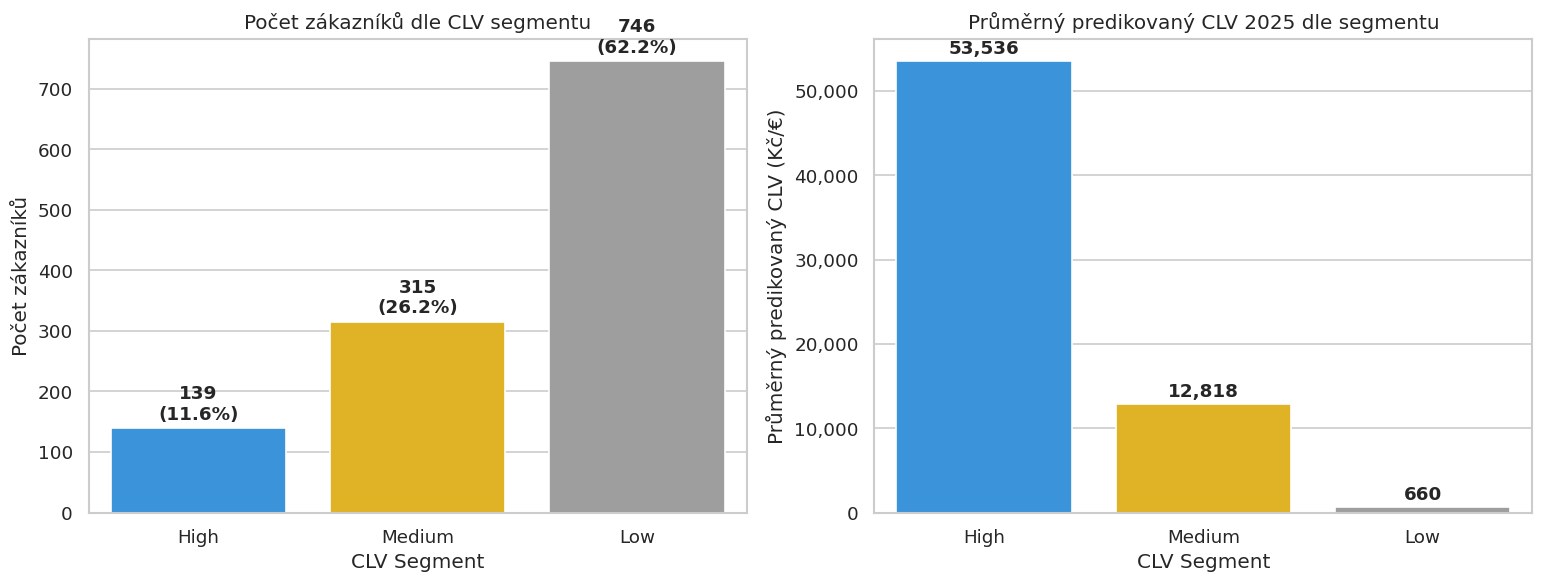

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Počty zákazníků v segmentech
seg_counts = df_final["clv_segment"].value_counts().reindex(SEGMENT_ORDER)
bars = sns.barplot(
    x=seg_counts.index, y=seg_counts.values,
    ax=axes[0],
    palette=[SEGMENT_COLORS[s] for s in SEGMENT_ORDER],
    order=SEGMENT_ORDER,
)
axes[0].set_title("Počet zákazníků dle CLV segmentu")
axes[0].set_xlabel("CLV Segment")
axes[0].set_ylabel("Počet zákazníků")
for bar, val in zip(axes[0].patches, seg_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 8,
        f"{val}\n({val/1200:.1%})",
        ha="center", va="bottom", fontsize=11, fontweight="bold",
    )

# Průměrný predikovaný CLV v segmentech
seg_avg_clv = df_final.groupby("clv_segment")["clv_2025_pred_xgb"].mean().reindex(SEGMENT_ORDER)
sns.barplot(
    x=seg_avg_clv.index, y=seg_avg_clv.values,
    ax=axes[1],
    palette=[SEGMENT_COLORS[s] for s in SEGMENT_ORDER],
    order=SEGMENT_ORDER,
)
axes[1].set_title("Průměrný predikovaný CLV 2025 dle segmentu")
axes[1].set_xlabel("CLV Segment")
axes[1].set_ylabel("Průměrný predikovaný CLV (Kč/€)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
for bar, val in zip(axes[1].patches, seg_avg_clv.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 400,
        f"{val:,.0f}",
        ha="center", va="bottom", fontsize=11, fontweight="bold",
    )

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step_07_segment_overview.png", dpi=150, bbox_inches="tight")
plt.show()


### 7.2 Distribuce predikovaného CLV dle segmentu

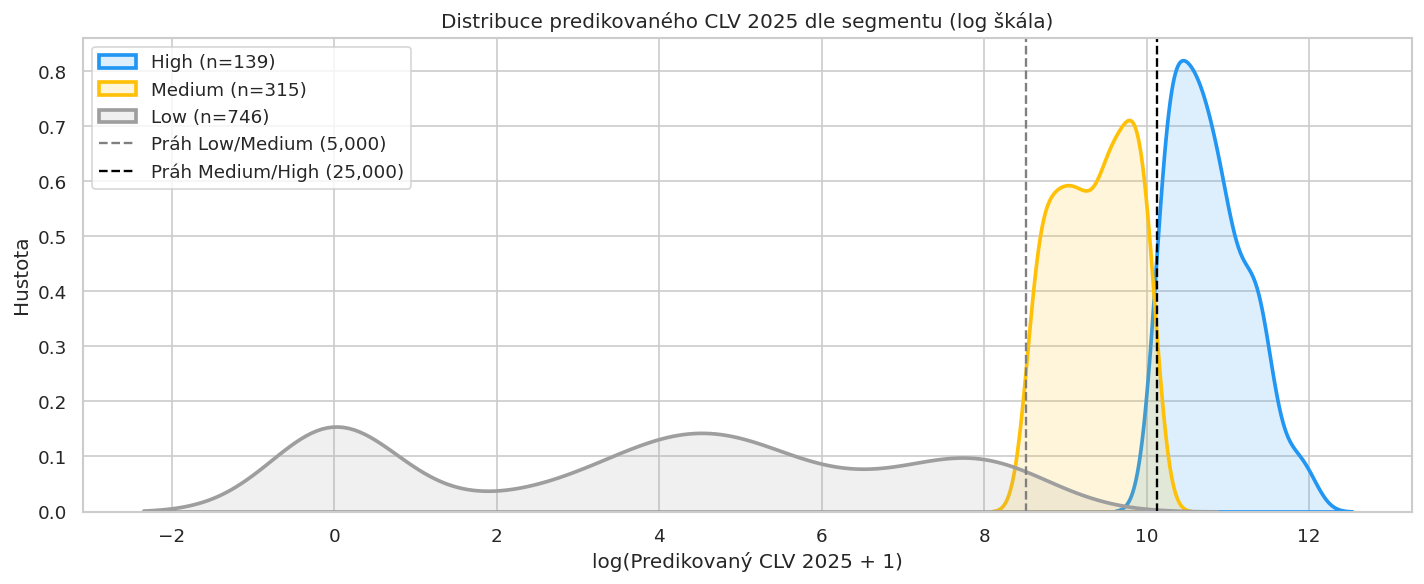

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))

for segment in SEGMENT_ORDER:
    data = df_final[df_final["clv_segment"] == segment]["clv_2025_pred_xgb"]
    sns.kdeplot(
        np.log1p(data),
        ax=ax,
        label=f"{segment} (n={len(data)})",
        color=SEGMENT_COLORS[segment],
        linewidth=2.2,
        fill=True,
        alpha=0.15,
    )

ax.axvline(np.log1p(CLV_THRESHOLD_LOW),    color="gray", lw=1.4,
           linestyle="--", label=f"Práh Low/Medium ({CLV_THRESHOLD_LOW:,})")
ax.axvline(np.log1p(CLV_THRESHOLD_MEDIUM), color="black", lw=1.4,
           linestyle="--", label=f"Práh Medium/High ({CLV_THRESHOLD_MEDIUM:,})")
ax.set_title("Distribuce predikovaného CLV 2025 dle segmentu (log škála)")
ax.set_xlabel("log(Predikovaný CLV 2025 + 1)")
ax.set_ylabel("Hustota")
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step_07_segment_clv_dist.png", dpi=150, bbox_inches="tight")
plt.show()


### 7.3 Složení segmentů dle Loyalty Tier

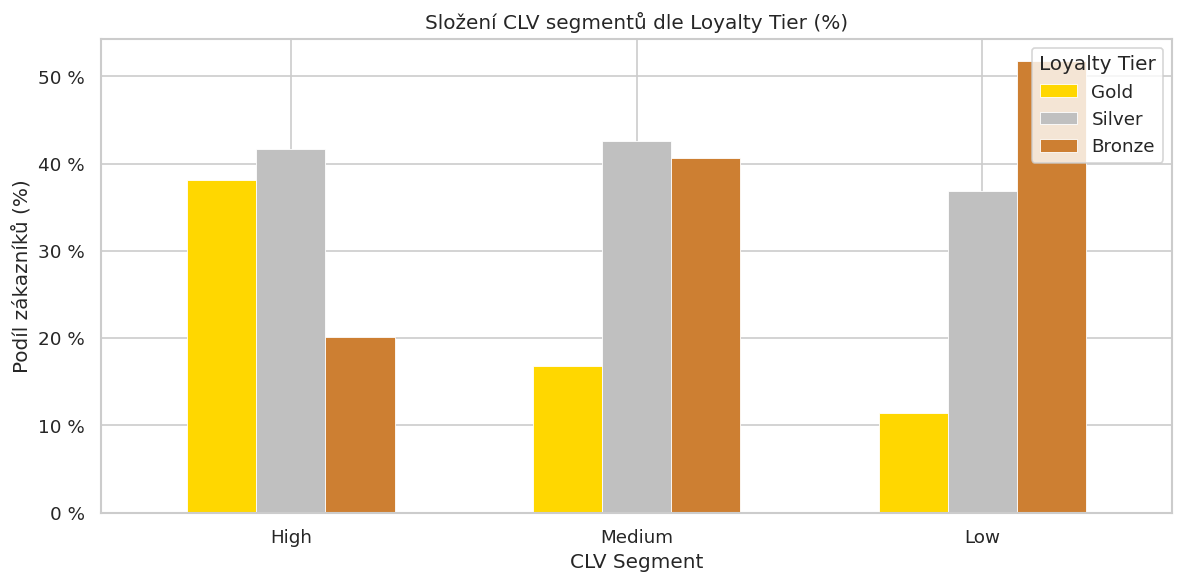

In [9]:
tier_seg = (
    pd.crosstab(
        df_final["clv_segment"],
        df_final["loyalty_tier_label"],
        normalize="index",
    )
    .reindex(SEGMENT_ORDER)
    [["Gold", "Silver", "Bronze"]]
    * 100
)

fig, ax = plt.subplots(figsize=(10, 5))

tier_seg.plot(
    kind="bar",
    ax=ax,
    color=["#FFD700", "#C0C0C0", "#CD7F32"],
    width=0.6,
    edgecolor="white",
    linewidth=0.5,
)
ax.set_title("Složení CLV segmentů dle Loyalty Tier (%)")
ax.set_xlabel("CLV Segment")
ax.set_ylabel("Podíl zákazníků (%)")
ax.set_xticklabels(SEGMENT_ORDER, rotation=0)
ax.legend(title="Loyalty Tier", loc="upper right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f} %"))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step_07_segment_tier_mix.png", dpi=150, bbox_inches="tight")
plt.show()


### 7.4 Klíčové features dle segmentu

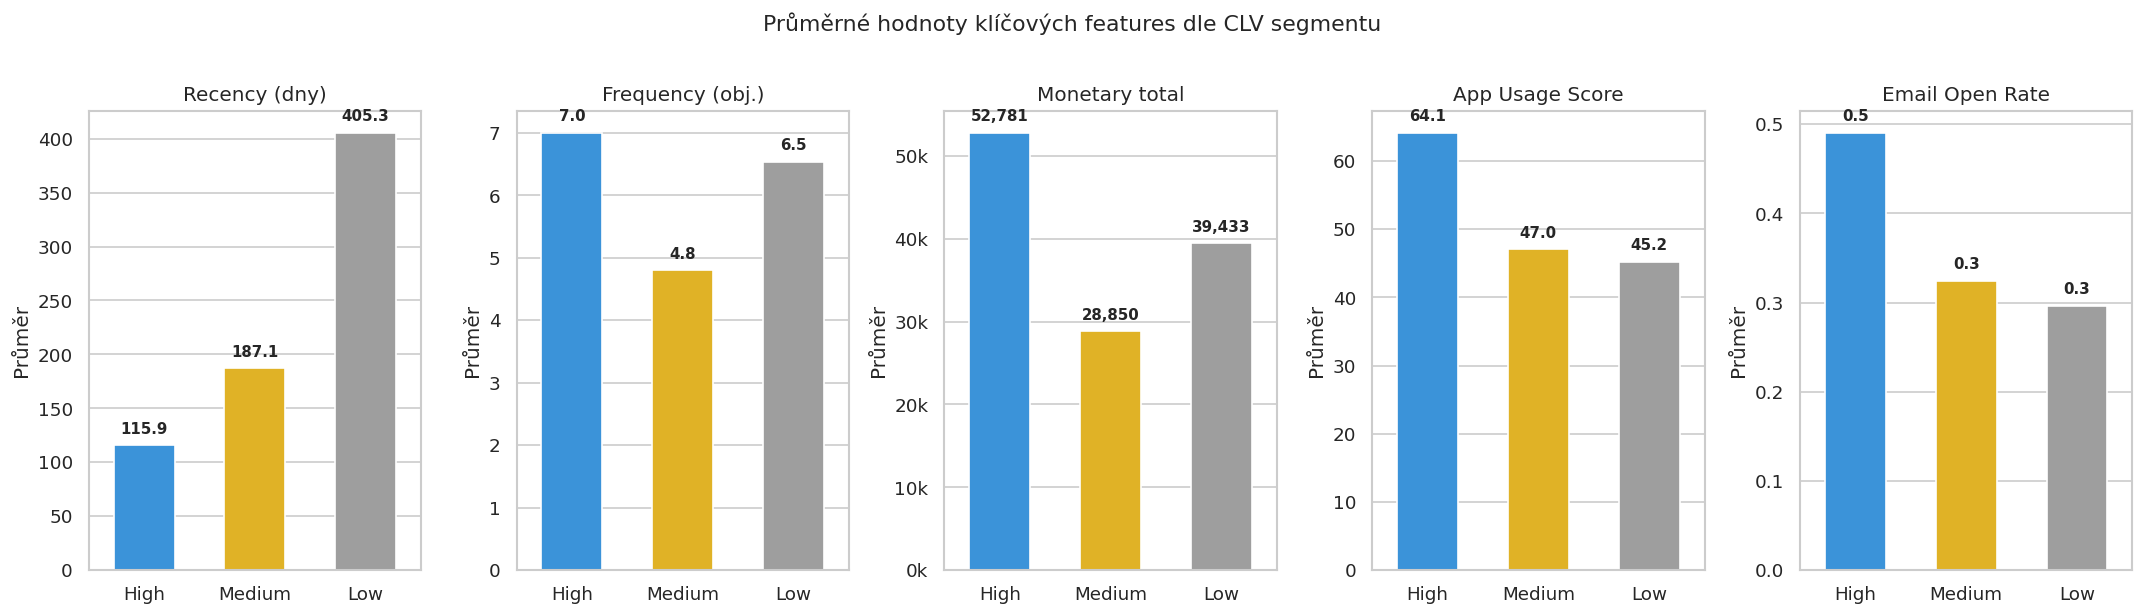

In [10]:
PROFILE_FEATURES = {
    "recency_days":     "Recency (dny)",
    "frequency":        "Frequency (obj.)",
    "monetary_total":   "Monetary total",
    "app_usage_score":  "App Usage Score",
    "email_open_rate":  "Email Open Rate",
}

fig, axes = plt.subplots(1, len(PROFILE_FEATURES), figsize=(18, 5))

for ax, (col, label) in zip(axes, PROFILE_FEATURES.items()):
    seg_means = (
        df_final.groupby("clv_segment")[col]
        .mean()
        .reindex(SEGMENT_ORDER)
    )
    sns.barplot(
        x=seg_means.index, y=seg_means.values,
        ax=ax,
        palette=[SEGMENT_COLORS[s] for s in SEGMENT_ORDER],
        order=SEGMENT_ORDER,
        width=0.55,
    )
    ax.set_title(label)
    ax.set_xlabel("")
    ax.set_ylabel("Průměr")
    if col == "monetary_total":
        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k")
        )
    for bar, val in zip(ax.patches, seg_means.values):
        fmt = f"{val:,.0f}" if col in ["monetary_total"] else f"{val:.1f}"
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + seg_means.max() * 0.02,
            fmt,
            ha="center", va="bottom", fontsize=9, fontweight="bold",
        )

plt.suptitle("Průměrné hodnoty klíčových features dle CLV segmentu", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step_07_segment_profiles.png", dpi=150, bbox_inches="tight")
plt.show()


### 7.5 Srovnání modelů — MAE, RMSE, R²

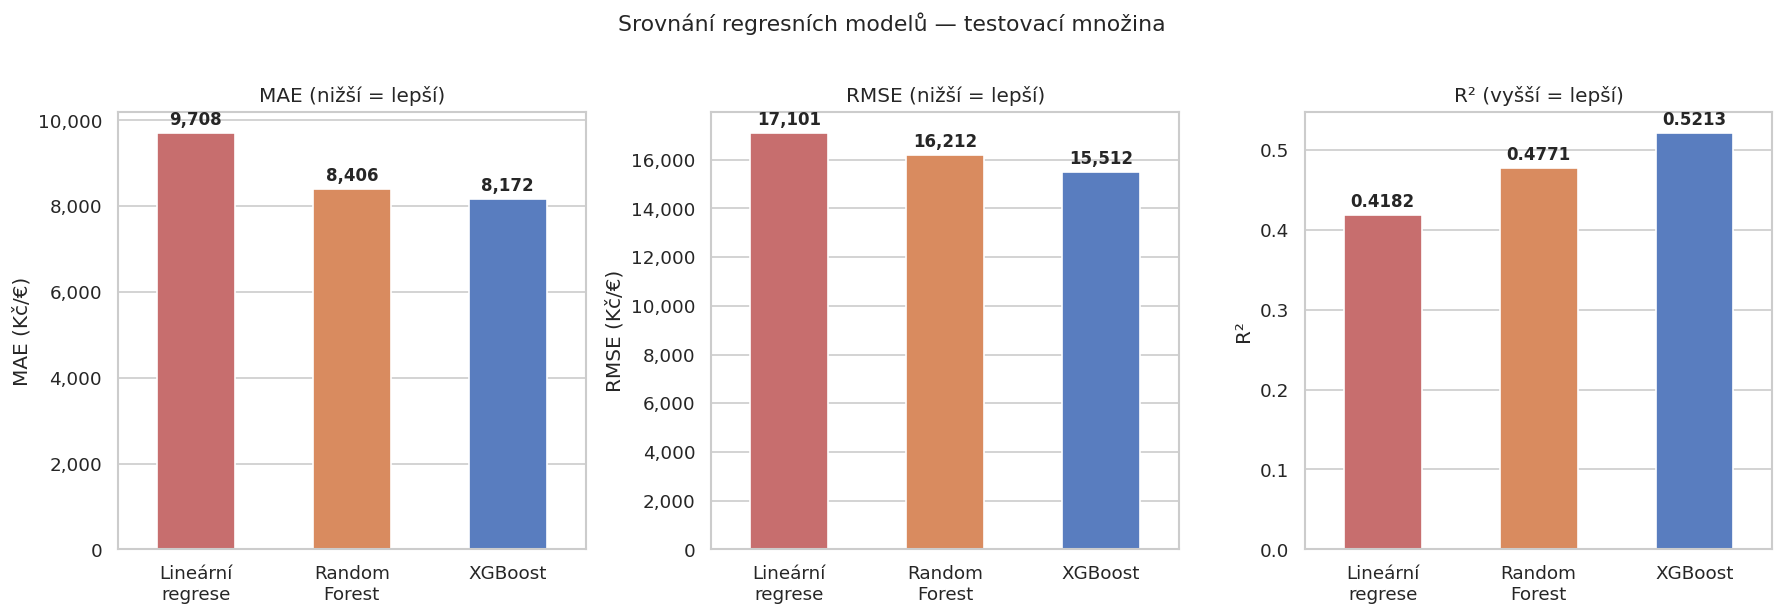

In [11]:
model_labels = ["Lineární\nregrese", "Random\nForest", "XGBoost"]
maes  = [int(metrics_lr.loc[0,"MAE"]),  int(metrics_rf.loc[0,"MAE"]),  int(metrics_xgb.loc[0,"MAE"])]
rmses = [int(metrics_lr.loc[0,"RMSE"]), int(metrics_rf.loc[0,"RMSE"]), int(metrics_xgb.loc[0,"RMSE"])]
r2s   = [metrics_lr.loc[0,"R2"],        metrics_rf.loc[0,"R2"],        metrics_xgb.loc[0,"R2"]]

COLORS = [sns.color_palette("muted")[3],
          sns.color_palette("muted")[1],
          sns.color_palette("muted")[0]]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, vals, title, ylabel in zip(
    axes,
    [maes, rmses, r2s],
    ["MAE (nižší = lepší)", "RMSE (nižší = lepší)", "R² (vyšší = lepší)"],
    ["MAE (Kč/€)", "RMSE (Kč/€)", "R²"],
):
    bars = sns.barplot(x=model_labels, y=vals, ax=ax, palette=COLORS, width=0.5)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    if "R²" not in title:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    for bar, val in zip(ax.patches, vals):
        fmt = f"{val:.4f}" if isinstance(val, float) else f"{val:,}"
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(vals) * 0.01,
            fmt,
            ha="center", va="bottom", fontsize=10, fontweight="bold",
        )

plt.suptitle("Srovnání regresních modelů — testovací množina", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step_07_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


### 7.6 Predikce vs. skutečnost — srovnání modelů na testovací množině

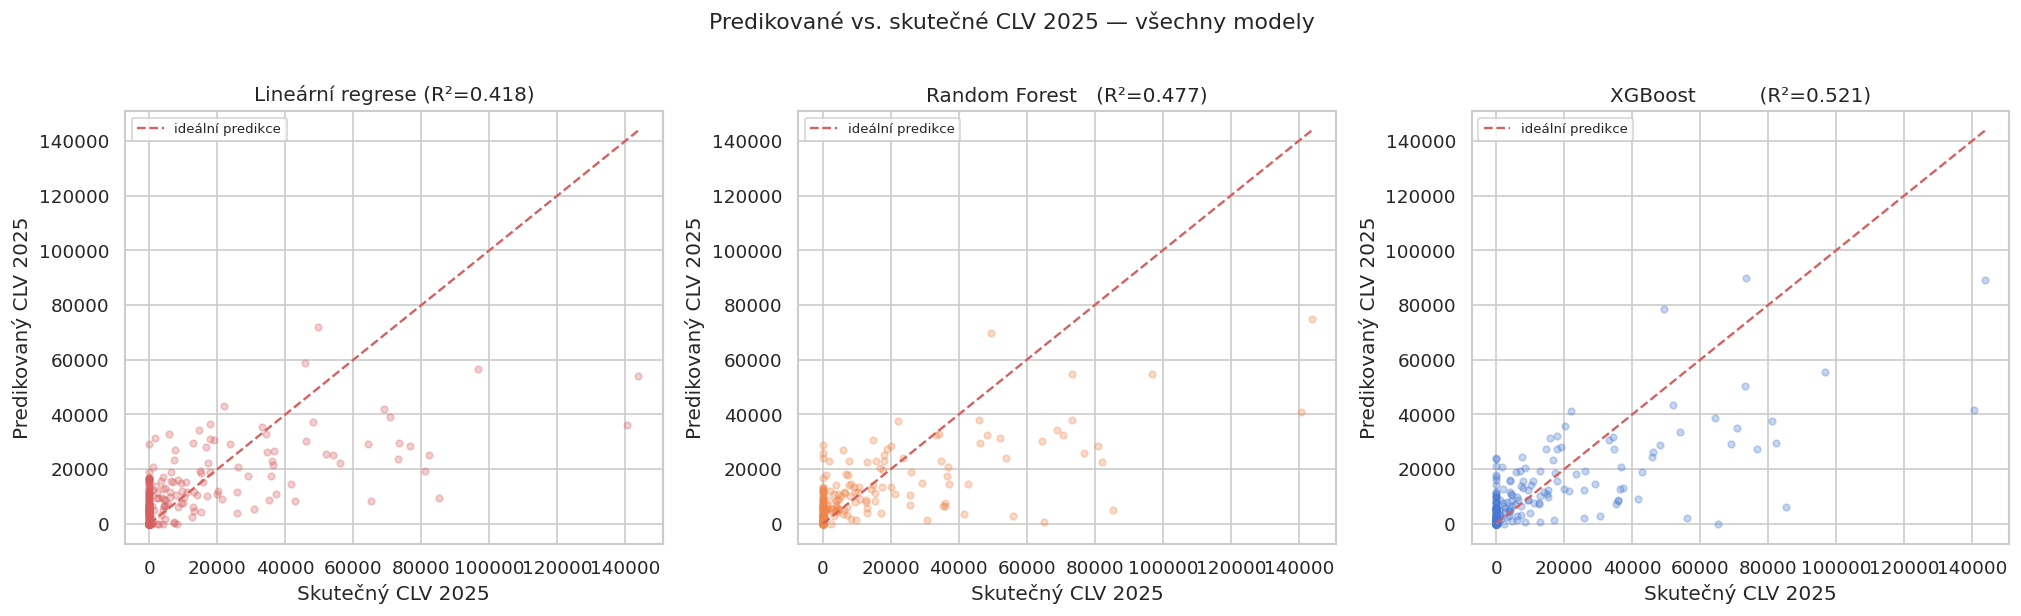

In [12]:
# Sloučení predikcí všech modelů na testovací množině
test_compare = (
    lr_preds.rename(columns={"clv_2025_pred_lr": "pred_lr"})
    .merge(
        rf_preds[["account_external_id", "clv_2025_pred_rf"]].rename(
            columns={"clv_2025_pred_rf": "pred_rf"}),
        on="account_external_id",
    )
    .merge(
        xgb_preds[["account_external_id", "clv_2025_pred_xgb"]].rename(
            columns={"clv_2025_pred_xgb": "pred_xgb"}),
        on="account_external_id",
    )
)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, col, title, color in zip(
    axes,
    ["pred_lr", "pred_rf", "pred_xgb"],
    [f"Lineární regrese (R²={metrics_lr.loc[0,'R2']:.3f})",
     f"Random Forest   (R²={metrics_rf.loc[0,'R2']:.3f})",
     f"XGBoost          (R²={metrics_xgb.loc[0,'R2']:.3f})"],
    [COLORS[0], COLORS[1], COLORS[2]],
):
    y_true = test_compare["clv_2025_actual"]
    y_pred = test_compare[col]
    ax.scatter(y_true, y_pred, alpha=0.3, s=16, color=color)
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([0, max_val], [0, max_val], "r--", lw=1.4, label="ideální predikce")
    ax.set_title(title)
    ax.set_xlabel("Skutečný CLV 2025")
    ax.set_ylabel("Predikovaný CLV 2025")
    ax.legend(fontsize=8)

plt.suptitle("Predikované vs. skutečné CLV 2025 — všechny modely", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step_07_all_models_pred_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Interpretace výsledků

**Segmentace rozdělila 1 200 zákazníků do tří skupin s výrazně odlišnými profily.**  
Segment High (139 zákazníků, 11,6 %) generuje průměrný predikovaný CLV 53 536 Kč/€  
a tvoří nadproporční část celkové predikované hodnoty zákaznické základny — právě  
tato skupina by měla být prioritou pro retention kampaně a personalizované nabídky.  
Segment Low (746 zákazníků, 62,2 %) má průměrný predikovaný CLV pouze 660 Kč/€,  
přičemž velká část zákazníků má predikci blízko nule — jsou to zákazníci s nízkou  
pravděpodobností nákupu nebo minimální hodnotou, kde marketingové náklady nejspíš  
nepřinesou pozitivní ROI.

**Profilové rozdíly mezi segmenty jsou ostré a konzistentní.**  
High zákazníci mají průměrnou recency pouhých 116 dní (nakoupili nedávno), 7 objednávek  
za 2022–2024 a app_usage_score 2× vyšší než Low segment. Naopak Low segment má recency  
průměrně 405 dní — tito zákazníci nenakoupili téměř rok před referenčním datem,  
což je silný signál churnu, který model správně zachytil.

**Složení segmentů dle Loyalty Tier odhaluje zajímavou heterogenitu.**  
Segment High je sice Gold-heavy (38 % Gold zákazníků vs. 20 % v Low), ale 41 %  
High zákazníků jsou Silver nebo Bronze — tito zákazníci mají vysoké predikované CLV  
přes behaviorální aktivitu, nikoli přes formální tier. To znamená, že firmě unikají  
potenciální Gold zákazníci, kteří jsou zatím podklasifikováni.

**Modely jako celek:** Logistická regrese s ROC-AUC 0.91 tvoří spolehlivý první filtr  
(kdo nakoupí / nenakoupí), XGBoost s R²=0.52 pak odhaduje výši CLV. Kombinace obou  
přístupů v dvoustupňovém modelu by mohla dále zlepšit business využitelnost predikcí —  
nejprve vyfiltrovat zákazníky s pravděpodobností nákupu > 50 %, pak pro ně predikovat CLV.


## 9. Finální výstup & Uložení

In [13]:
# Finální zákaznická tabulka — business výstup
try:
    df_output.to_csv(OUTPUT_DIR / "step_07_clv_segments.csv",
                     index=False, encoding="utf-8-sig")
    print("✅ Zákaznická tabulka uložena: step_07_clv_segments.csv")
    print(f"   Řádků: {len(df_output)}, Sloupců: {df_output.shape[1]}")
except Exception as e:
    print(f"❌ Chyba při ukládání: {e}")

# Souhrnná statistika segmentů
try:
    segment_stats.to_csv(OUTPUT_DIR / "step_07_segment_stats.csv", encoding="utf-8-sig")
    print("✅ Segmentové statistiky uloženy: step_07_segment_stats.csv")
except Exception as e:
    print(f"❌ Chyba: {e}")

# Kompletní srovnání modelů
comparison_all = pd.concat([
    comparison_reg,
    pd.DataFrame({
        "Model": ["— Logistická regrese (klasifikace) —"],
        "MAE": ["—"], "RMSE": ["—"], "R²": [0.9101],
        "MAE (aktivní zákazníci)": ["ROC-AUC"],
        "R² (aktivní zákazníci)": ["—"],
    })
], ignore_index=True)
try:
    comparison_all.to_csv(OUTPUT_DIR / "step_07_model_comparison.csv", index=False)
    print("✅ Srovnání modelů uloženo: step_07_model_comparison.csv")
except Exception as e:
    print(f"❌ Chyba: {e}")

print()
print("=" * 55)
print("  PROJEKT CLV PREDIKCE 2025 — DOKONČEN")
print("=" * 55)
print(f"  Zákazníků celkem:          1 200")
print(f"  High CLV segment:          {n_high:>4}  ({n_high/1200:.1%})")
print(f"  Medium CLV segment:        {n_medium:>4}  ({n_medium/1200:.1%})")
print(f"  Low CLV segment:           {n_low:>4}  ({n_low/1200:.1%})")
print(f"  Nejlepší model:            XGBoost")
print(f"  Nejlepší R²:               {metrics_xgb.loc[0,'R2']:.4f}")
print(f"  Nejlepší MAE:              {int(metrics_xgb.loc[0,'MAE']):,} Kč/€")
print(f"  Klasifikace ROC-AUC:       0.9101")
print("=" * 55)


✅ Zákaznická tabulka uložena: step_07_clv_segments.csv
   Řádků: 1200, Sloupců: 13
✅ Segmentové statistiky uloženy: step_07_segment_stats.csv
✅ Srovnání modelů uloženo: step_07_model_comparison.csv

  PROJEKT CLV PREDIKCE 2025 — DOKONČEN
  Zákazníků celkem:          1 200
  High CLV segment:           139  (11.6%)
  Medium CLV segment:         315  (26.2%)
  Low CLV segment:            746  (62.2%)
  Nejlepší model:            XGBoost
  Nejlepší R²:               0.5213
  Nejlepší MAE:              8,172 Kč/€
  Klasifikace ROC-AUC:       0.9101


## Shrnutí projektu

### Co bylo vytvořeno
Kompletní, reprodukovatelný ML pipeline pro predikci Customer Lifetime Value v 7 samostatných  
Jupyter Noteboocích. Každý notebook je plně self-contained — načítá CSV výstup předchozího  
kroku a produkuje vlastní výstupy (PNG grafy, CSV data, metriky).

### Datový základ
Z 4 Excel sheetů (1 200 zákazníků, ~9 500 objednávek) byl sestaven kompletní feature set  
o 29 features rozdělených do skupin RFM, behaviorálních a profilových bez jediné chybějící hodnoty.

### Modely a výsledky

| Krok | Model | Typ | Klíčová metrika |
|------|-------|-----|----------------|
| 3 | Lineární regrese | Regrese | R² = 0.418, MAE = 9 708 |
| 4 | Logistická regrese | Klasifikace | ROC-AUC = 0.910 |
| 5 | Random Forest | Regrese | R² = 0.477, MAE = 8 406 |
| **6** | **XGBoost** | **Regrese** | **R² = 0.521, MAE = 8 172** |

### Doporučení pro business
- **High segment** (139 zákazníků) — priorita pro VIP retention, personalizace, upsell
- **Medium segment** (315 zákazníků) — potenciál pro upgrade, cílené kampaně
- **Low segment** (746 zákazníků) — nízkonákladová reaktivace nebo churn acceptance
- Zákazníci Silver/Bronze v High segmentu jsou kandidáti na přeřazení do Gold tieru
